# Fig. — Robustness to imperfect CSI (pilot-power sweep)

Loader/summary helpers come from `build_fig_csi.py`; **`build_figure` is inlined
below as an editable cell**. Plots **all** algorithms (graceful-vs-cliff contrast).

- **(top)** communication metric vs pilot power. `COMM_METRIC`:
  `'min'` (min-user SINR), `'mean'` (mean-user SINR), or `'outage'`
  (per-user Pr(SINR<γ\*) — the reliability cliff). For `'outage'`, γ\* is auto-detected.
- **(bottom)** SCNR vs pilot power. `SCNR_METRIC`: `'wsum'` (default), `'min'`, `'mean'`.
- `BAND`: `'std'` (default), `'iqr'`, or `'none'`.
- Dashed line marks the operating point P_p\* (= `PILOT_POWER_DB`, 128 dB).

**Compatible experiment:** `csi_sweep` (`kind=='sweep'`).

In [1]:
import sys, logging
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

FIG_DIR = Path.cwd()
if str(FIG_DIR) not in sys.path:
    sys.path.insert(0, str(FIG_DIR))

import build_fig_csi as B   # loader + helpers (single source of truth)
from cordis.plotting import apply_paper_style, figsize, plot_sweep, style_for, save_figure
from cordis.plotting.style import ALGORITHM_STYLE   # tweak here to restyle

USE_TEX = True   # set False on a node without pdflatex
apply_paper_style()
logging.basicConfig(level=logging.INFO, format='%(levelname)-7s %(message)s')

## 1. Load the pilot-power-sweep run

In [2]:
RESULT_DIR = None   # e.g. 'results/exp_csi_sweep/array_12345_aggregated'
result, result_dir = B.load_sweep(RESULT_DIR, experiment='csi_sweep')
print('run:', result_dir)
print('pilot grid [dB]:', sorted(result.sweep_results.keys()))

run: /Users/mehdi/Local-Drive/GitHub/CORDIS/results/exp_csi_sweep/array_52882237_aggregated
pilot grid [dB]: [80.0, 90.0, 100.0, 110.0, 120.0, 130.0, 140.0]


## 2. Knobs: comm metric, SCNR metric, band, operating point

In [4]:
COMM_METRIC = 'min'    # 'min' | 'mean' (SINR)  |  'outage' (per-user Pr(SINR<γ*))
SCNR_METRIC = 'wsum'   # 'wsum' | 'min' | 'mean'
BAND        = 'std'    # 'std' | 'iqr' | 'none'
PILOT_STAR  = 128.0    # operating point (marked)
GAMMA_DB    = None     # None -> auto-detect γ* (only used by COMM_METRIC='outage')
ONLY        = None     # None -> ALL algorithms (trio leading)

only = ['Centralized', 'CORDIS-Split', 'CORDIS-ADMM', 'Global-ZF',
        'Global-MRT', r'LR-MMSE ($\rho$=0.5)']  # B._ordered_algorithms(result, B.LEAD, only=(ONLY or None))
scnr_name, _, _ = B._resolve_scnr_metric(SCNR_METRIC, result, only)
gamma_db, detected = (GAMMA_DB, True) if GAMMA_DB is not None else B._detect_gamma_db(result)
sinr_name = ('min_sinr_db' if COMM_METRIC=='outage' else B._resolve_sinr_metric(COMM_METRIC)[0])
comm_label = ('outage Pout' if COMM_METRIC=='outage' else B._resolve_sinr_metric(COMM_METRIC)[1])
print('algorithms:', only)
print('comm:', COMM_METRIC, '| scnr:', scnr_name, '| band:', BAND, '| γ*:', gamma_db, f'(detected={detected})')

algorithms: ['Centralized', 'CORDIS-Split', 'CORDIS-ADMM', 'Global-ZF', 'Global-MRT', 'LR-MMSE ($\\rho$=0.5)']
comm: min | scnr: weighted_sum_scnr_db | band: std | γ*: 5.0 (detected=True)


## 3. Numeric summary (caption sanity check)

Comm metric at worst-CSI / operating / best-CSI pilot power, the best−worst change
(small = graceful, large = cliff), and the SCNR change.

In [5]:
summary = B.collect_summary(result, only, COMM_METRIC, sinr_name, scnr_name, gamma_db, PILOT_STAR)
B._print_summary(result, summary, COMM_METRIC, comm_label, scnr_name, gamma_db, PILOT_STAR)

[info] pilot grid = [80.0, 90.0, 100.0, 110.0, 120.0, 130.0, 140.0] dB
[info] P_p* (mark)= 128 dB  (nearest swept 130 dB)
[info] comm metric= min-user SINR
[info] SCNR metric= weighted_sum_scnr_db
algorithm     min-user SI worst       op     best  Δ(best-worst)  SCNR drop
---------------------------------------------------------------------------
Centralized            -24.936    5.001    5.001         29.937      6.560
CORDIS-Split           -37.534    5.063    7.079         44.613      2.491
CORDIS-ADMM            -44.422    5.000    5.001         49.423      1.074
Global-ZF              -49.419   18.128   19.502         68.921     -3.689
Global-MRT             -60.531    0.682    1.430         61.961      1.116
LR-MMSE ($\rho$=0.5)         -24.936   13.743   15.639         40.575     -0.468


## 4. `build_figure` — editable copy

The **exact** function from `build_fig_csi.py`, inlined so you can edit it and re-run.
Mutate `ALGORITHM_STYLE` in the setup cell to restyle without editing the body.

In [6]:
# Bind the module-level names the function body references.
from typing import Optional, Sequence
LEAD                 = B.LEAD
COMM_METRIC_DEFAULT  = B.COMM_METRIC_DEFAULT
SCNR_METRIC_DEFAULT  = B.SCNR_METRIC_DEFAULT
BAND_DEFAULT         = B.BAND_DEFAULT
GAMMA_DB_DEFAULT     = B.GAMMA_DB_DEFAULT
PILOT_STAR_DEFAULT_DB= B.PILOT_STAR_DEFAULT_DB
_ordered_algorithms  = B._ordered_algorithms
_resolve_sinr_metric = B._resolve_sinr_metric
_resolve_scnr_metric = B._resolve_scnr_metric
_outage_xy           = B._outage_xy
_in_range            = B._in_range
logger               = logging.getLogger('fig_csi.nb')

In [84]:
def build_figure(result,
                 *,
                 only: Optional[Sequence[str]] = None,
                 comm_metric: str = COMM_METRIC_DEFAULT,
                 scnr_metric: str = SCNR_METRIC_DEFAULT,
                 band: str = BAND_DEFAULT,
                 gamma_db: float = GAMMA_DB_DEFAULT,
                 pilot_star: float = PILOT_STAR_DEFAULT_DB,
                 log_x: bool = False,
                 use_tex: bool = True):
    """Assemble the stacked CSI-robustness figure; return
    ``(fig, only, scnr_metric_name)``.

    ``comm_metric`` is 'min'|'mean' (SINR) or 'outage' (per-user Pr(SINR<γ\\*));
    ``scnr_metric`` is 'min'|'mean'|'wsum'; ``band`` is 'std'|'iqr'|'none'.
    """
    import matplotlib
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False
    import matplotlib.pyplot as plt
    from cordis.plotting import apply_paper_style, figsize, plot_sweep, style_for

    apply_paper_style()
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False

    # IEEE standard font sizes
    IEEE_FONT_SIZE = 9
    plt.rcParams.update({
        "font.size": IEEE_FONT_SIZE,
        "axes.labelsize": IEEE_FONT_SIZE + 2,
        "xtick.labelsize": IEEE_FONT_SIZE,
        "ytick.labelsize": IEEE_FONT_SIZE,
        "legend.fontsize": IEEE_FONT_SIZE,
        "legend.title_fontsize": IEEE_FONT_SIZE,
        "figure.titlesize": IEEE_FONT_SIZE,
        "axes.titlesize": IEEE_FONT_SIZE,
    })
    LW = 2
    MARKER_SIZE = 6

    only = list(only) if only else _ordered_algorithms(result, LEAD)
    scnr_name, scnr_full, _scnr_short = _resolve_scnr_metric(scnr_metric, result, only)

    axis = result.sweep_axis
    xlabel = axis.display or r"Pilot power $P_p/\sigma_n^2$ [dB]"

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=figsize(width="double", aspect=4 / 3),
        sharex=True, gridspec_kw={"hspace": 0.12},
    )

    # (top) communication metric vs pilot power
    if comm_metric == "outage":
        for n in only:
            xs, line, lo, hi = _outage_xy(result, n, gamma_db, band)
            if not xs:
                continue
            st = style_for(n)
            ax_top.plot(xs, line, label=st.get("label", n),
                        color=st.get("color"), marker=st.get("marker", "o"),
                        ls=st.get("linestyle", "-"))
            if band in ("std", "iqr") and lo:
                ax_top.fill_between(xs, lo, hi, color=st.get("color"),
                                    alpha=0.15, linewidth=0)
        if log_x:
            ax_top.set_xscale("log")
        ax_top.set_ylim(bottom=0.0)
        ax_top.set_ylabel(rf"$P_{{\mathrm{{out}}}}$ at $\gamma\!=\!{gamma_db:g}$ dB")
        ax_top.grid(True, alpha=0.3)
        if ax_top.get_legend_handles_labels()[0]:
            ax_top.legend(loc="best", fontsize=6)
    else:
        sinr_name, sinr_label = _resolve_sinr_metric(comm_metric)
        plot_sweep(result.sweep_results, metric=sinr_name, ax=ax_top, error=band,
                   xlabel="", ylabel=f"{sinr_label} [dB]", only=only, log_x=log_x)
    # ax_top.set_title("Robustness to imperfect CSI")
    ax_top.legend(loc="best", bbox_to_anchor=(0.62, 0.62),
                  framealpha=0.5, ncol=1)

    # (bot) SCNR vs pilot power
    if scnr_name is not None:
        plot_sweep(result.sweep_results, metric=scnr_name, ax=ax_bot, error=band,
                   xlabel=xlabel, ylabel=f"{scnr_full} [dB]", only=only, log_x=log_x)
    else:
        logger.warning("No SCNR metric available; bottom panel left empty.")
        ax_bot.set_xlabel(xlabel)

    # operating-point marker P_p* (only if inside the swept range)
    if _in_range(result, pilot_star):
        for ax in (ax_top, ax_bot):
            ax.axvline(pilot_star, ls="--", lw=1, color="0.45", zorder=0)
            for line in ax.lines:
                line.set_markersize(MARKER_SIZE)      # Change marker size
                line.set_linewidth(LW)
        ax_top.text(pilot_star*1.025, 0.15, r"$P_p^\star$",
                    transform=ax_top.get_xaxis_transform(),
                    ha="right", va="top", fontsize=14, color="0.35")
    else:
        logger.warning("pilot_star=%.3g dB is outside the swept range; "
                       "operating-point marker skipped.", pilot_star)

    # one legend only (top); drop the duplicate on the bottom panel
    if ax_bot.get_legend() is not None:
        ax_bot.get_legend().remove()

    # NB: no fig.tight_layout() — conflicts with the shared-x / hspace stacked
    # layout.  save_figure() uses bbox_inches='tight'.
    return fig, only, scnr_name


## 5. Render

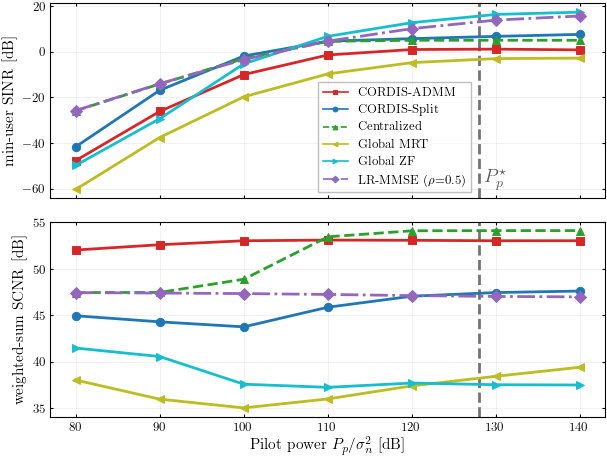

In [85]:
fig, used_only, used_scnr_metric = build_figure(
    result, only=only, comm_metric='min', scnr_metric='wsum',
    band='none', gamma_db=gamma_db, pilot_star=PILOT_STAR, use_tex=USE_TEX,
)
plt.show()

## 6. Save to `paper/figures/`

In [86]:
tag = ''
out_stem = FIG_DIR.parents[1] / 'figures' / str('fig_csi' + tag)
paths = save_figure(
    fig, out_stem, formats=('pdf', 'png'),
    metadata={
        'Figure': 'fig_csi', 'PilotStarDB': f'{PILOT_STAR:g}',
        'CommMetric': COMM_METRIC + (f'(gamma={gamma_db:g})' if COMM_METRIC=='outage' else ''),
        'ScnrMetric': str(used_scnr_metric), 'Band': BAND,
        'Algorithms': ', '.join(used_only), 'Run': result_dir.name,
    },
)
for p in paths:
    print('wrote', p)

wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_csi.pdf
wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_csi.png
